# Shopping Habits of Instacart Customers

## Introduction
The project is based on the data from Instacart, a grocery delivery platform where customers can place a grocery order and have it delivered to them. 

This particular dataset was publicly released by Instacart in 2017 for a Kaggle competition, and will be working on the modified version of the data. 

The aim of this project is to clean up the data which includes five tables and prepare a report that gives insight into the shopping habits of Instacart customers.

## Libraries

In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

## Data Overview
### Load the Datasets

In [2]:
orders = pd.read_csv('./datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('./datasets/products.csv', sep=';')
aisles = pd.read_csv('./datasets/aisles.csv', sep=';')
departments = pd.read_csv('./datasets/departments.csv', sep=';')
order_products = pd.read_csv('./datasets/order_products.csv', sep=';')

### Exploring the data

#### Orders

In [3]:
orders.info() # We have missing values in the days_since_prior_order column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


#### Products

In [5]:
products.info()

products.head() # Missing values in the product_name column. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


#### Aisles

In [6]:
aisles.info()

aisles.head() # No missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


#### Departments

In [7]:
departments.info()

departments.head() #No missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


#### Order products

In [8]:
order_products.info(show_counts=True)

order_products.head()  # Missing values in the add_to_cart_order column. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


In [9]:
order_products.shape

(4545007, 4)

In [10]:
order_products.sample(20)

,order_id,product_id,add_to_cart_order,reordered
2494390,3248894,26629,5.0,1
3096093,489636,17630,20.0,1
4026667,965785,6046,4.0,0
4332430,2676932,30325,2.0,0
2893637,3319670,37646,4.0,1
1362631,733109,4565,8.0,0
4505333,1345587,19048,9.0,1
4025683,2484110,27690,6.0,1
1262329,3357679,25890,5.0,1
862881,163987,25087,3.0,0


### Descriptive Statistics of all the DataFrames

In [11]:
# Display descriptive statistics of the 'orders' DataFrame
orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,4.789670e+05,478967.000000,478967.000000,478967.000000,478967.000000,450148.000000
mean,1.709947e+06,102966.537475,17.157808,2.775058,13.446676,11.101751
std,9.869480e+05,59525.328991,17.704688,2.045869,4.224986,9.189975
min,4.000000e+00,2.000000,1.000000,0.000000,0.000000,0.000000
25%,8.564685e+05,51414.000000,5.000000,1.000000,10.000000,4.000000
50%,1.709522e+06,102633.000000,11.000000,3.000000,13.000000,7.000000
75%,2.562990e+06,154419.000000,23.000000,5.000000,16.000000,15.000000
max,3.421079e+06,206209.000000,100.000000,6.000000,23.000000,30.000000


In [12]:
# Display descriptive statistics of the 'products' DataFrame
products.describe()

,product_id,aisle_id,department_id
count,49694.000000,49694.000000,49694.000000
mean,24847.500000,67.773192,11.728478
std,14345.566475,38.317265,5.850314
min,1.000000,1.000000,1.000000
25%,12424.250000,35.000000,7.000000
50%,24847.500000,69.000000,13.000000
75%,37270.750000,100.000000,17.000000
max,49694.000000,134.000000,21.000000


In [13]:
# Display the descriptive statistics of the 'aisles' DataFrame
aisles.describe()

,aisle_id
count,134.000000
mean,67.500000
std,38.826537
min,1.000000
25%,34.250000
50%,67.500000
75%,100.750000
max,134.000000


In [14]:
# Display the descriptive statistics of the 'departments' DataFrame
departments.describe()

,department_id
count,21.000000
mean,11.000000
std,6.204837
min,1.000000
25%,6.000000
50%,11.000000
75%,16.000000
max,21.000000


In [15]:
# Dislay descriptive statistics of the 'orders_products' DataFrame
order_products.describe()

,order_id,product_id,add_to_cart_order,reordered
count,4.545007e+06,4.545007e+06,4.544171e+06,4.545007e+06
mean,1.711166e+06,2.558084e+04,8.351669e+00,5.905025e-01
std,9.850955e+05,1.409552e+04,7.080368e+00,4.917411e-01
min,4.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.608170e+05,1.353500e+04,3.000000e+00,0.000000e+00
50%,1.711530e+06,2.527200e+04,6.000000e+00,1.000000e+00
75%,2.561311e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421079e+06,4.969400e+04,6.400000e+01,1.000000e+00


## Duplicates

### `orders` data frame

In [16]:
# Check for duplicated orders
orders.duplicated().sum() #looking at the entire dataframe for duplicate rows and count them

15

The dictionary tells us that:
- **order_dow** = day of the week that the order placed (which day is 0 is uncertain)
- **order_hour_of_day** = hour of the day that the order was placed

We know these are type INT. We can look at the values for the 'order_hour_of_day' column to figure out what value is being used for 2 AM == 2. We don't know what day of the week the calendar starts on to understand what is Wednesday. Assuming that the value is 3. 

In [17]:
# Check for all orders placed Wednesday at 2:00 AM

weds_orders = orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)]

display(weds_orders)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


In [18]:
# Remove duplicate orders
orders = orders.drop_duplicates()

In [19]:
# Double check for duplicate rows
orders.duplicated().sum() #looking at the entire dataframe for duplicate rows and count them

0

In [20]:
# Double check for duplicate order IDs only
display(orders[orders.duplicated(subset='order_id')])

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


### `products` data frame

In [21]:
# Check for fully duplicate rows
products.duplicated().sum()


0

In [22]:
# Check for just duplicate product IDs
products.duplicated(subset='product_id').sum() 


0

In [23]:
# Check for just duplicate product names (convert names to lowercase to compare better)
products['product_name'] = products['product_name'].str.lower()

total_dup = products['product_name'].duplicated().sum()

display(total_dup)

1361

In [24]:
# Check for duplicate product names that aren't missing

#how many are nans? 
missing = products['product_name'].isna().sum()

display(missing)

tot_not_missing = total_dup - missing
display(tot_not_missing)

# filtering with two logical expressions
# negating isna() to hide missing values
# return dataframe, expecting 103

not_null = products[~(products['product_name'].isna()) & (products['product_name'].duplicated())] 

display(not_null) #my result is a total of 104. I was expectig 103, but I'm not sure where I went wrong here? 


1258

103

,product_id,product_name,aisle_id,department_id
2058,2059,biotin 1000 mcg,47,11
5455,5456,green tea with ginseng and honey,96,20
5558,5559,cream of mushroom soup,69,15
7558,7559,cinnamon rolls with icing,105,13
9037,9038,american cheese slices,21,16
...,...,...,...,...
49689,49690,high performance energy drink,64,7
49690,49691,original pancake & waffle mix,130,14
49691,49692,organic instant oatmeal light maple brown sugar,130,14
49692,49693,spring water body wash,127,11


### `departments` data frame

In [25]:
#look for duplicate values
departments.duplicated().sum() #check for duplicate rows

0

In [26]:
#this question asks for duplicate values, so we'll check each column too

departments['department_id'].duplicated().sum()

0

In [27]:
departments['department'].duplicated().sum()

0

### `aisles` data frame

In [28]:
#look for duplicate values
aisles.duplicated().sum()

0

In [29]:
aisles['aisle_id'].duplicated().sum() #checking each column for duplicate values

0

In [30]:
aisles['aisle'].duplicated().sum()

0

### `order_products` data frame

In [31]:
# Check for duplicated row
order_products.duplicated().sum()  

0

In [32]:
# Double check for any other tricky duplicates
order_products.duplicated(subset=['order_id', 'product_id']).sum() #look at a couple of columns


0

In [33]:
(~order_products.duplicated()).sum() #count the number of non-duplicates; this result matches the shape. 

4545007

## Find and remove missing values


### `products` data frame

In [34]:
products.isna().sum() #check the missing values

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

In [35]:
# Are all of the missing product names associated with aisle ID 100?

products.aisle_id.value_counts() # how many values are there for aisle id 100? 

aisle_id
100    1258
45     1246
37     1091
47     1038
120    1026
       ... 
113      47
82       44
32       32
68       26
18       12
Name: count, Length: 134, dtype: int64

In [36]:
missing_products = products[(products['product_name'].isna()) & (products['aisle_id'] != 100)]

display(missing_products.info())   # answer confirmed... yes, all of the missing values are for aisle id 100. 

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     0 non-null      int64 
 1   product_name   0 non-null      object
 2   aisle_id       0 non-null      int64 
 3   department_id  0 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 0.0+ bytes


None

In [37]:
# Are all of the missing product names associated with department ID 21?
missing_product_depts = products[(products['product_name'].isna()) & (products['department_id'] == 21)]

display(missing_product_depts.info())  #Yes. The resulting total matches our the total number of missing values

<class 'pandas.core.frame.DataFrame'>
Index: 1258 entries, 37 to 49668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     1258 non-null   int64 
 1   product_name   0 non-null      object
 2   aisle_id       1258 non-null   int64 
 3   department_id  1258 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 49.1+ KB


None

In [38]:
# What is this aisle and department?

mystery_product = products[(products['aisle_id'] == 100) & (products['department_id'] == 21)]

display(mystery_product.product_id.nunique()) # It's a mystery. The product ids are all unqiue. 

1258

In [39]:
# Fill missing product names with 'Unknown'

products['product_name'] = products['product_name'].fillna(value='Unknown')

### `orders` data frame

In [40]:
orders.isna().sum() #identify missing values

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [41]:
# Are there any missing values where it's not a customer's first order?

first_order = orders[(orders['days_since_prior_order'].isna())]

display(first_order.sort_values(by=['order_number']))



,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
320427,2573704,92897,1,3,9,NaN
320413,1411305,169247,1,0,8,NaN
320391,2300293,32810,1,0,13,NaN
320389,228858,107288,1,5,10,NaN
...,...,...,...,...,...,...
160310,1801395,116168,1,1,7,NaN
160285,1253128,198314,1,3,14,NaN
160276,1027108,138219,1,0,13,NaN
159668,402920,57451,1,5,0,NaN


The missing values are all for a customers' first order. 

* I didn't see a task to do something with the missing values here? Did I miss this?

### `order_products` data frame

In [42]:
#check on the missing values
order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [43]:
# What are the min and max values in this column
order_products.add_to_cart_order.min()

1.0

In [44]:
order_products.add_to_cart_order.max()

64.0

In [45]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
order_missing_order = order_products[(order_products['add_to_cart_order'].isna())]

display(order_missing_order.info())

<class 'pandas.core.frame.DataFrame'>
Index: 836 entries, 737 to 4535739
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           836 non-null    int64  
 1   product_id         836 non-null    int64  
 2   add_to_cart_order  0 non-null      float64
 3   reordered          836 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 32.7 KB


None

In [46]:
# Do all orders with missing values have more than 64 products?
products_per_order = order_missing_order.groupby('order_id').size() #size tells us the number of rows in each group

products_per_order.max() # No, the orders with missing values have 63 or less products. 

63

No, the orders with missing values have 63 or less products. 

In [47]:
# Replace missing values with 999 and convert column to integer type
order_products['add_to_cart_order'].fillna(999, inplace=True)

order_products.info(show_counts=True) #confirm the change

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4545007 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [48]:
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype('int') #convert using astype()

order_products.info(show_counts=True) #confirm the change

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           4545007 non-null  int64
 1   product_id         4545007 non-null  int64
 2   add_to_cart_order  4545007 non-null  int64
 3   reordered          4545007 non-null  int64
dtypes: int64(4)
memory usage: 138.7 MB


## Analyzing the Data

### Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

In [49]:
display(orders.order_hour_of_day.min())
display(orders.order_hour_of_day.max())

display(orders.order_dow.min())
display(orders.order_dow.max())

0

23

0

6

### What time of day do people shop for groceries?

In [50]:
time_to_shop = orders.groupby('order_hour_of_day').size()  

display(time_to_shop.sort_values(ascending=False))

order_hour_of_day
10    40578
11    40032
15    39789
14    39631
13    39007
16    38112
12    38034
9     35896
17    31930
18    25510
8     25024
19    19547
20    14624
7     13043
21    11019
22     8512
23     5611
6      4215
0      3180
1      1763
5      1371
2       989
3       770
4       765
dtype: int64

10 AM is the most popular time

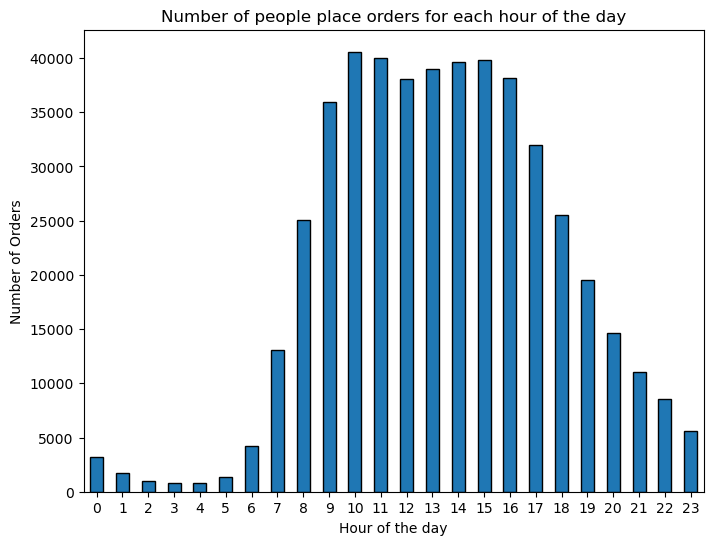

In [76]:
## Create a plot that shows how many people place orders for each hour of the day.
plt.figure(figsize=(8, 6))
time_to_shop.plot(kind='bar',  
                                title='Number of people place orders for each hour of the day',
                                xlabel='Hour of the day',
                                ylabel='Number of Orders',
                                edgecolor='black',
                                rot=0)  # Keep the x-axis labels horizontal for readability

plt.show()

Most of the orders were placed between 7AM until 8PM as shown in the graph.

### What day of the week do people shop for groceries?

In [52]:
# Assign the days of the week to the order_dow values
day_people_shop_groceries = orders['order_dow'].value_counts().sort_index()
day_people_shop_groceries.index =['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
print(day_people_shop_groceries)

Sunday       84090
Monday       82185
Tuesday      65833
Wednesday    60897
Thursday     59810
Friday       63488
Saturday     62649
Name: count, dtype: int64


In [53]:
orders.groupby('order_dow').size() 


order_dow
0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
dtype: int64

Sunday

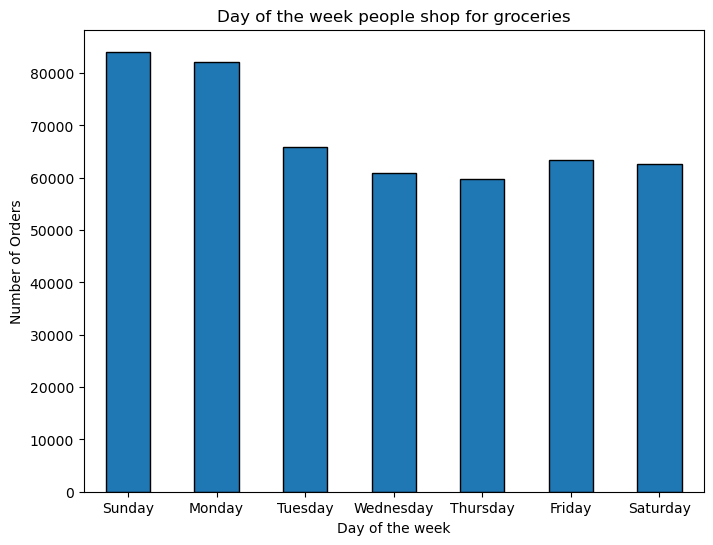

In [77]:
## Create a plot that shows what day of the week people shop for groceries.
plt.figure(figsize=(8, 6))
day_people_shop_groceries.plot(kind='bar', 
                                title='Day of the week people shop for groceries',
                                xlabel='Day of the week',
                                ylabel='Number of Orders',
                                edgecolor='black',
                                rot=0)  # Keep the x-axis labels horizontal for readability

plt.show()

### How long do people wait until placing another order?

In [55]:
order_wait = orders.groupby('days_since_prior_order')['days_since_prior_order'].count() #count() only counts the non-null values, so I chose this and not size()

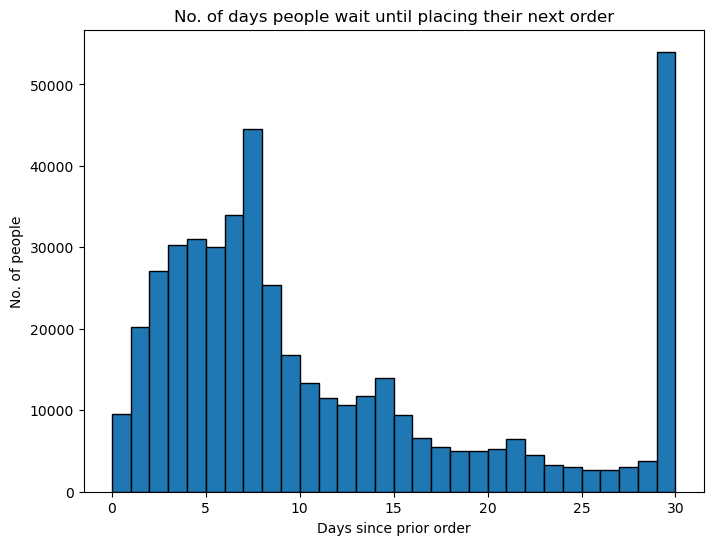

In [78]:
## Create a plot that shows how long people wait until placing their next order, and comment on the minimum and maximum values.
plt.figure(figsize = (8, 6))
plt.hist(orders['days_since_prior_order'], 
         bins=30, 
         edgecolor='black')
plt.title('No. of days people wait until placing their next order')
plt.xlabel('Days since prior order')
plt.ylabel('No. of people')
plt.show()

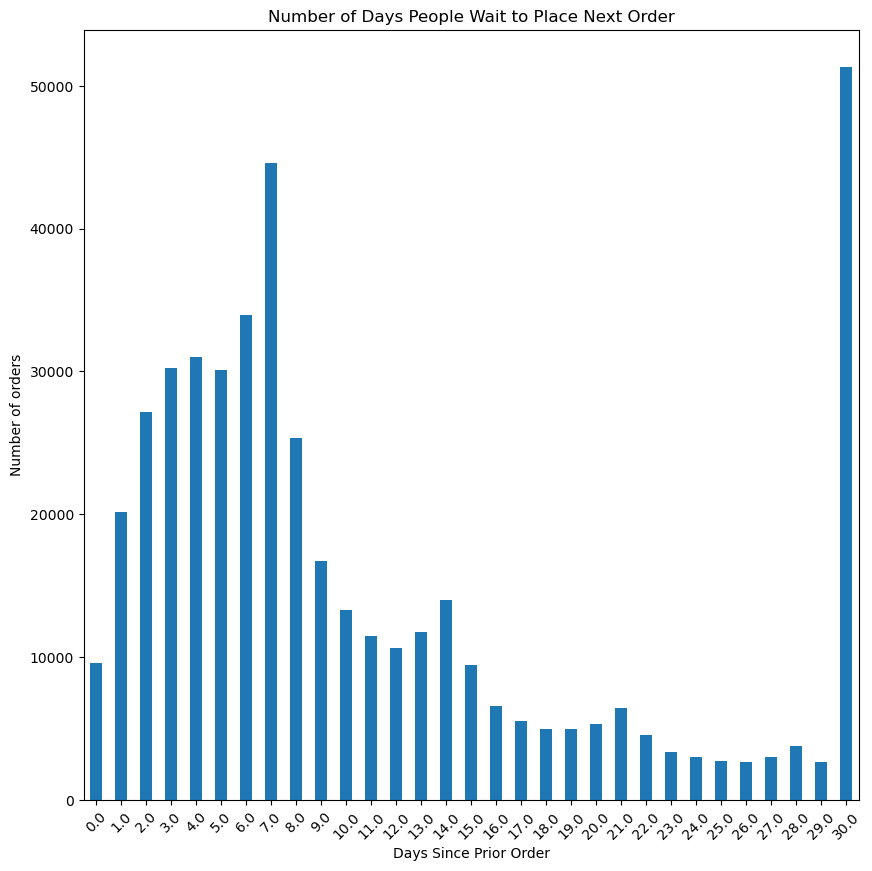

In [57]:
order_wait.plot(title="Number of Days People Wait to Place Next Order",
                kind="bar",
                
                xlabel = "Days Since Prior Order",
                ylabel = "Number of orders",
                figsize = (10,10),
                rot = 45
               )

plt.show()

In [58]:
# Find the minimum and maximum values
min_days = orders['days_since_prior_order'].min()
max_days = orders['days_since_prior_order'].max()

# Comment on the minimum and maximum value
print(f"The minimum number of days between orders is: {min_days}")
print(f"The maximum number of days between orders is: {max_days}")

The minimum number of days between orders is: 0.0
The maximum number of days between orders is: 30.0


In [59]:
orders.days_since_prior_order.median() #we have some outliers with the 30.0 days, so I thought I'd use median

7.0

There are a lot of people who reorder right away and quite a few people who wait quite some time before placing another order. 

7 days

### Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the histograms for both days and describe the differences that you see.

In [60]:
# Filter orders placed on Wednesday
wed_orders = orders[orders['order_dow'] == 3]
display(wed_orders.head())

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
6,2511640,148233,40,3,8,2.0
16,3109465,55090,19,3,15,9.0
28,133707,182261,1,3,10,NaN
30,1890318,193501,3,3,15,30.0
35,125325,106853,6,3,19,30.0


In [61]:
# Filter orders placed on Saturday
sat_orders = orders[orders['order_dow'] == 6]
display(sat_orders.head())

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
11,102585,191558,18,6,16,8.0
14,2843219,74699,4,6,11,30.0
20,50934,178510,9,6,9,5.0
26,1844247,122558,4,6,18,30.0


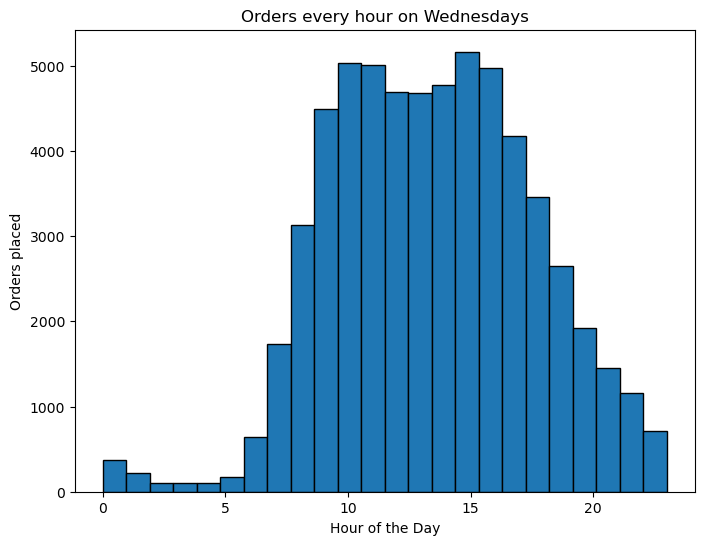

In [62]:
# Create a plot that shows how many orders are placed every hour on Wednesdays
plt.figure(figsize=(8, 6))
plt.hist(wed_orders['order_hour_of_day'], 
         bins=24, 
         edgecolor='black')
plt.title('Orders every hour on Wednesdays')
plt.xlabel('Hour of the Day')
plt.ylabel('Orders placed')
plt.show()

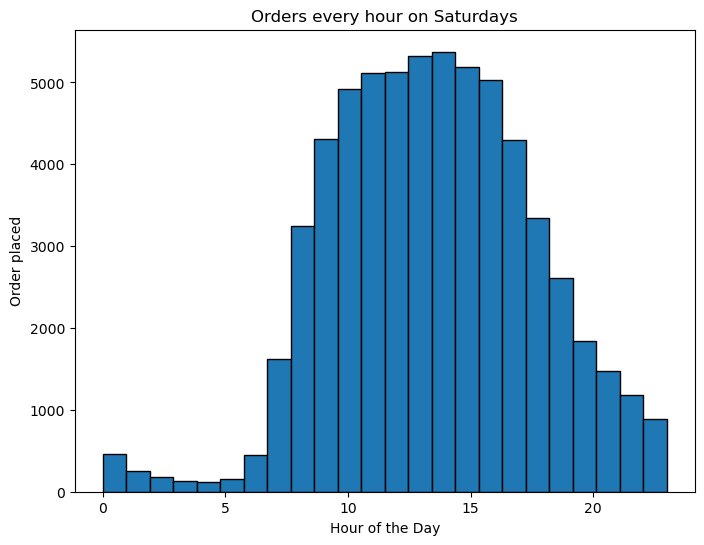

In [63]:
# Create a plot that shows how many orders are placed every hour on Saturdays
plt.figure(figsize=(8, 6))
plt.hist(sat_orders['order_hour_of_day'], 
         bins=24, 
         edgecolor='black')
plt.title('Orders every hour on Saturdays')
plt.xlabel('Hour of the Day')
plt.ylabel('Order placed')
plt.show()

The distribution of the orders placed every hour on Wednesdays and Saturdays are similar. 

Both the graphs are right skewed, which shows that there are less order placed after midnight. 

After almost 6 AM, the number of orders placed increased and were increasing until next couple hours. 

The only difference I can see when comparing the orders placed on Weds and Sat are during peak hour, which are from 10 AM - 5 PM. On Weds., there are less orders placed during those peak hours compared to orders placed on Sat. As Weds. is a weekday and Sat a weekend, more people place orders during peak hours compare to Weds., when people have work next day.

### What's the distribution for the number of orders per customer?

In [64]:
# Determine the average number of orders per customer
orders_per_customer = orders.groupby('user_id')['order_id'].count()
orders_per_customer.describe()

count    157437.000000
mean          3.042182
std           2.746842
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          28.000000
Name: order_id, dtype: float64

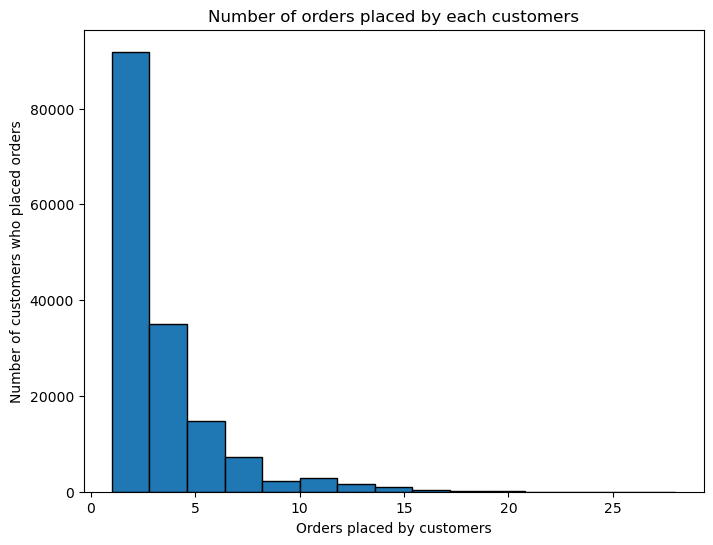

In [65]:
# Create a plot that shows how many orders are placed by each customer
plt.figure(figsize=(8, 6))
plt.hist(orders_per_customer, 
         bins=15, 
         edgecolor='black')
plt.title('Number of orders placed by each customers')
plt.xlabel('Orders placed by customers')
plt.ylabel('Number of customers who placed orders')
plt.show()

### What are the top 20 popular products (display their id and name)?

In [66]:
# Merge the 'products' and 'order_products' DataFrames on 'product_id'
data_merge = products.merge(order_products,
                           on='product_id')

# Merge the 'aisles' DataFrame on 'aisle_id'
data_merge = data_merge.drop('aisle_id',
                              axis='columns')

# Merge the 'departments' DataFrame on 'department_id'
data_merge = data_merge.drop('department_id', 
                             axis='columns')

# Merge the 'orders' DataFrame on 'order_id'
data_merge = data_merge.drop('product_name',
                              axis='columns')
display(data_merge.head())

,product_id,order_id,add_to_cart_order,reordered
0,1,1104373,11,1
1,1,1774977,4,1
2,1,652770,10,0
3,1,1000035,6,1
4,1,1679949,9,0


In [67]:
# Determine the top 20 products ordered

# Count the number of times each product was ordered
order_count = data_merge['product_id'].value_counts()

# Create a DataFrame with the product IDs and their order counts
top_20_product_ids = order_count.head(20).index
top_20_products = products[products['product_id'].isin(top_20_product_ids)]
top_20_products = top_20_products.drop('aisle_id', axis='columns')
top_20_products = top_20_products.drop('department_id', axis='columns')

display(top_20_products.head())

,product_id,product_name
5875,5876,organic lemon
8276,8277,apple honeycrisp organic
13175,13176,bag of organic bananas
16796,16797,strawberries
21136,21137,organic strawberries


Based on the product names of the top 20 popular products, it can be seen that most of the top 20 product names were of organic food items, while there are some fruits and vegetables such as lemons, limes, bananas, strawberries, and cucumber - kirby. 

### How many items do people typically buy in one order? What does the distribution look like?

In [68]:
# Determine the number of items bought by people in one order

# Count the number of items in each order
items_per_order = order_products.groupby('order_id').size()
display("The distribution of the items bought by people in one order:")

# Display the distribution of items per order
items_per_order.describe()

'The distribution of the items bought by people in one order:'

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
dtype: float64

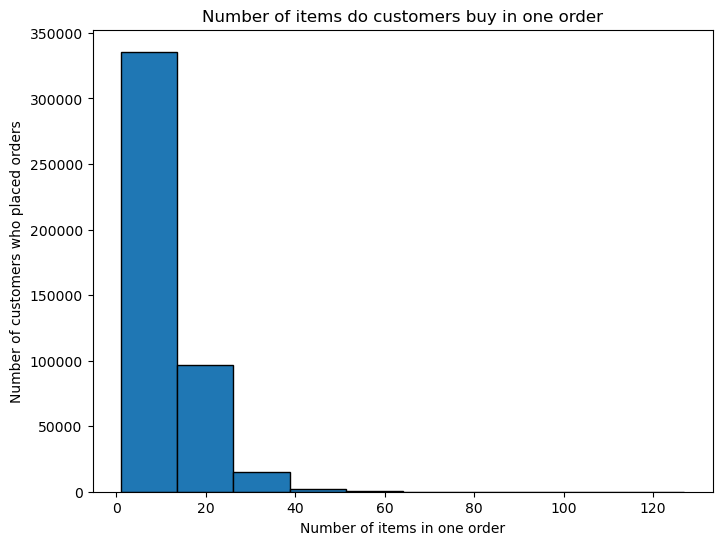

In [69]:
# Create a plot that shows how many items do customers buy in one order
plt.figure(figsize=(8, 6))
plt.hist(items_per_order, 
         bins=10, 
         edgecolor='black')
plt.title('Number of items do customers buy in one order')
plt.xlabel('Number of items in one order')
plt.ylabel('Number of customers who placed orders')
plt.show()


People typically buy 10 items per order. 

The graph above illustrates that the range of the items bought by the customers in one order on instacart is from 1 - 60. The average number of items customers bought in an order are 20 items, but half the customers have 8 items in an order. From the distibution of the items bought by people in one order, it can be known that most of the customers had bought atleast one item in an order on instacart, while few had bouught almost 127 items in an order. Half of the customers had bought 8 items in an order.

### What are the top 20 items that are reordered most frequently?

In [70]:
# Determine the number of items reordered by customers

# Filter the orders_products DataFrame for reordered items
reorder_items = order_products[order_products['reordered'] == 1]

# Count the number of times each product was reordered
reorder_counts = reorder_items.groupby('product_id')['order_id'].count().reset_index()
display(reorder_counts.head())

,product_id,order_id
0,1,158
1,3,31
2,4,25
3,7,1
4,8,6


In [71]:
# Add a column for the number of times each product was reordered
reorder_counts.columns = ['product_id', 'reorder_count']

# Sort the DataFrame by reorder_count in descending order to get the top 20 reordered products
top_20_reordered = reorder_counts.sort_values(by='reorder_count', ascending=False).head(20)
display(top_20_reordered.head())

,product_id,reorder_count
18104,24852,55763
9528,13176,44450
15368,21137,28639
15936,21903,26233
34407,47209,23629


In [72]:
# Merge the top 20 reordered products with the products DataFrame to get product names
top_20_reordered = products.merge(top_20_reordered,
                           on='product_id')

# Drop unnecessary columns
display(top_20_reordered[['product_id', 'product_name', 'reorder_count']].sort_values(by='reorder_count', ascending=False))

,product_id,product_name,reorder_count
7,24852,banana,55763
2,13176,bag of organic bananas,44450
4,21137,organic strawberries,28639
5,21903,organic baby spinach,26233
15,47209,organic hass avocado,23629
17,47766,organic avocado,18743
10,27845,organic whole milk,16251
16,47626,large lemon,15044
11,27966,organic raspberries,14748
3,16797,strawberries,13945


### What are the top 20 items that people put in their carts first?

In [73]:
# Filter for the first item in each order
first_items = order_products[order_products['add_to_cart_order'] == 1]

In [74]:
# Count the number of times each product is the first item in the cart
first_item_counts = first_items['product_id'].value_counts()

# Get the top 20 products by frequency of being the first item
top_20_first_items_ids = first_item_counts.head(20).index

In [75]:
# Merge with products to get product names
top_20_first_items = products[products['product_id'].isin(top_20_first_items_ids)]

display(top_20_first_items[['product_id', 'product_name']])

,product_id,product_name
195,196,soda
5784,5785,organic reduced fat 2% milk
12340,12341,hass avocados
13175,13176,bag of organic bananas
16796,16797,strawberries
19659,19660,spring water
21136,21137,organic strawberries
21902,21903,organic baby spinach
24851,24852,banana
26208,26209,limes


The data illustrates that the top 20 items that people put in their carts first includes items thare are among the top popular items and among the ones reordered most frequently. Along with those natural and organic items, it also includes soda becoming the top items among the list of items which are placed in the cart first.

## Conclusions

### Shopping trends we uncovered in the analysis

**Most popular shopping times:**
- 10 AM on Sunday

**Order trends:**
- People either make their next order quickly or wait until 30 days,
- And typically buy 10 items per order.

While the most popular items ordered are fruits and veggies, the most popular reordered items are packaged goods. 
